# Spectral Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os

/Users/jasonc/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jasonc/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jasonc/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
consumer_df = pd.read_parquet("/Users/jasonc/Desktop/DSC_291/cashflow/consumer_data.parquet")

In [3]:
# Example of one splitted transction:
consumer_1 = pd.read_parquet("/Users/jasonc/Desktop/DSC_291/split_transactions/C01100001.parquet")

In [4]:
consumer_df

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id
0,1629936000000000000,0.0,1380.84,C01100001
1,1659398400000000000,0.0,20163.90,C01100002
2,1614816000000000000,0.0,3986.25,C01100003
3,1668816000000000000,0.0,5956.03,C01100004
4,1637452800000000000,0.0,29421.10,C01100005
...,...,...,...,...
4995,1680220800000000000,0.0,1412.80,C04104996
4996,1680220800000000000,0.0,-439.21,C04104997
4997,1680220800000000000,0.0,84.53,C04104998
4998,1680220800000000000,0.0,52655.88,C04104999


In [5]:
consumer_1

,masked_consumer_id,posted_date,amount,category,masked_transaction_id
0,C01100001,1624924800000000000,926.89,4.0,C01T00
1,C01100001,1605484800000000000,300.00,0.0,C01T01
2,C01100001,1606262400000000000,500.00,0.0,C01T02
3,C01100001,1599091200000000000,1000.00,0.0,C01T03
4,C01100001,1604880000000000000,200.00,0.0,C01T04
...,...,...,...,...,...
2653,C01100001,1615161600000000000,-7000.00,1.0,C01T02653
2654,C01100001,1601424000000000000,-17.12,19.0,C01T02654
2655,C01100001,1606089600000000000,-3.99,20.0,C01T02655
2656,C01100001,1621209600000000000,-53.00,27.0,C01T02656


First let's plot the spending trend for one consumer:

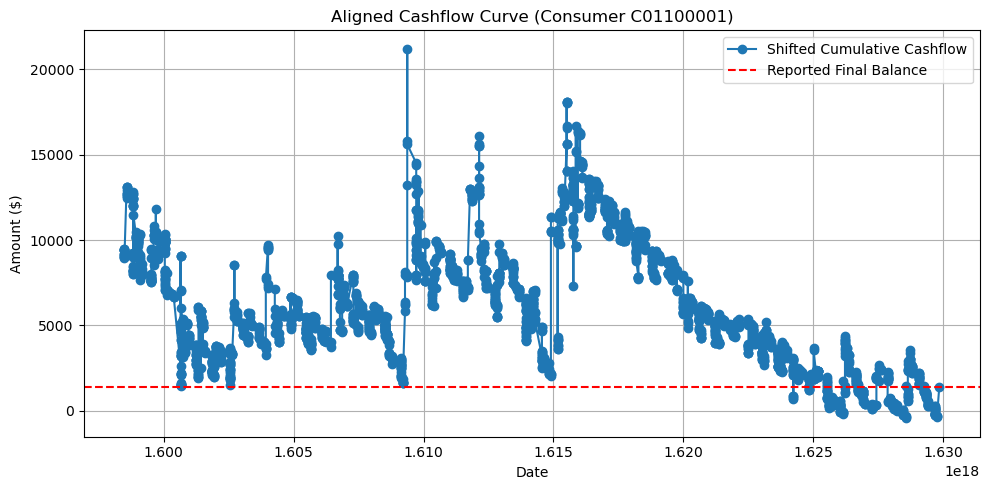

In [6]:
# Get consumer ID and final reported balance
cid = consumer_1['masked_consumer_id'].iloc[0]
final_balance = consumer_df.loc[consumer_df['masked_consumer_id'] == cid, 'total_balance'].values[0]

# Compute cumulative cashflow
consumer_1 = consumer_1.sort_values('posted_date')
consumer_1['cumulative_cashflow'] = consumer_1['amount'].cumsum()

# Shift so that final cumulative value aligns with reported balance
calc_final = consumer_1['cumulative_cashflow'].iloc[-1]
offset = final_balance - calc_final
consumer_1['shifted_cashflow'] = consumer_1['cumulative_cashflow'] + offset

# Plot shifted cumulative cashflow
plt.figure(figsize=(10, 5))
plt.plot(consumer_1['posted_date'], consumer_1['shifted_cashflow'], marker='o', label='Shifted Cumulative Cashflow')
plt.axhline(y=final_balance, color='red', linestyle='--', label='Reported Final Balance')
plt.title(f"Aligned Cashflow Curve (Consumer {cid})")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Since this can be treated as a time-series sequence, we can use spectral analysis to extract their spending pattern:

In [7]:
# Ensure datetime type
consumer_1['posted_date'] = pd.to_datetime(consumer_1['posted_date'])

# Then set it as the index and aggregate
ts_daily = (
    consumer_1
    .set_index('posted_date')
    .resample('D')['shifted_cashflow']
    .sum()
)

# Fill missing days
ts_daily = ts_daily.ffill()
ts_weekly = ts_daily.resample('W').sum()

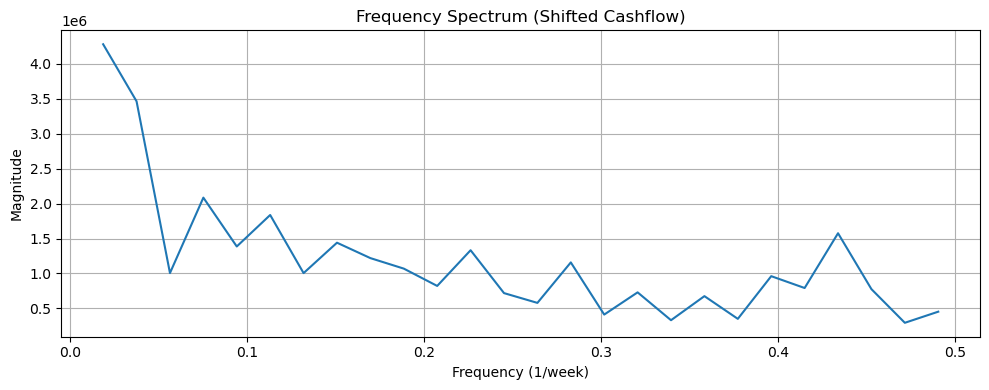

In [8]:
# Detrend: remove mean
ts_detrended = ts_weekly - ts_weekly.mean()

# FFT
fft_vals = np.fft.fft(ts_detrended)
fft_freqs = np.fft.fftfreq(len(ts_detrended), d=1)

# Take only positive frequencies
pos_mask = fft_freqs > 0
fft_mags = np.abs(fft_vals)[pos_mask]
fft_freqs = fft_freqs[pos_mask]

# Plot frequency spectrum
plt.figure(figsize=(10, 4))
plt.plot(fft_freqs, fft_mags)
plt.title("Frequency Spectrum (Shifted Cashflow)")
plt.xlabel("Frequency (1/week)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

This will show the spending pattern for each consumer, but for different consumers, the length of transactions might be different...

We will have to extract key components from each cash flow. We can extract these features:

| Feature Name        | Description |
|---------------------|-------------|
| **dominant_freq**   | The frequency (in cycles per day) with the highest spectral power, excluding the zero-frequency component. Indicates the strongest periodic pattern in the consumer’s cashflow (e.g., ~0.033 ≈ 1 cycle every 30 days). |
| **dominant_power**  | The magnitude (power) of the dominant frequency component. Reflects how strong the consumer’s dominant spending/income cycle is. |
| **spectral_entropy**| Entropy of the normalized power spectrum, measuring how spread out the frequency content is. Low entropy = concentrated signal (predictable), high entropy = noisy or irregular behavior. |
| **low_freq_power**  | Total spectral power in low frequencies (default: below 0.05 cycles/day), representing long-term trends or slow oscillations (e.g., monthly patterns). |
| **high_freq_power** | Total spectral power in high frequencies (default: above 0.25 cycles/day), representing rapid fluctuations (e.g., daily or erratic behavior). |
| **power_ratio**     | The ratio of low-frequency to high-frequency power, used to quantify the smoothness or volatility of the consumer’s financial activity. High values suggest more stability or periodicity. |

These features can be used as input to machine learning models to predict default risk.

We wanna do the following:
1. **Resampling**: Ensures that the time series is uniformly sampled at daily intervals (with missing values filled as zero).
2. **Detrending**: Subtracts the mean from the time series to remove the constant (DC) component.
3. **FFT**: Applies the Fast Fourier Transform to convert the signal from the time domain to the frequency domain.
4. **Power Spectrum**: Computes squared magnitudes of FFT values, representing the signal's power at each frequency.
5. **Normalization**: Normalizes power values to compute entropy and compare across series of different scales.
6. **Feature Extraction**: Returns a dictionary of key spectral features.

In [9]:
from scipy.stats import entropy

def extract_fft_features(ts, detrend=True, low_freq_cut=0.05, high_freq_cut=0.25):
    """
    ts: pandas Series indexed by datetime (e.g., daily cashflow)
    Returns: dict of frequency-based features
    """
    # Ensure evenly spaced (e.g., daily)
    ts = ts.asfreq('D').fillna(0)

    # Detrend
    if detrend:
        ts = ts - ts.mean()

    # FFT
    fft_vals = np.fft.fft(ts)
    fft_freqs = np.fft.fftfreq(len(ts), d=1)

    # Remove DC and negative freqs
    pos_mask = fft_freqs > 0
    freqs = fft_freqs[pos_mask]
    mags = np.abs(fft_vals)[pos_mask]
    power = mags**2
    power_norm = power / power.sum()

    # Features
    dominant_idx = np.argmax(power)
    dominant_freq = freqs[dominant_idx]
    dominant_power = power[dominant_idx]
    spectral_entropy = entropy(power_norm)

    # Band powers
    low_power = power[(freqs < low_freq_cut)].sum()
    high_power = power[(freqs > high_freq_cut)].sum()
    power_ratio = low_power / (high_power + 1e-6)

    return {
        "dominant_freq": dominant_freq,
        "dominant_power": dominant_power,
        "spectral_entropy": spectral_entropy,
        "low_freq_power": low_power,
        "high_freq_power": high_power,
        "power_ratio": power_ratio,
    }

In [10]:
# Ensure date is datetime
consumer_1['posted_date'] = pd.to_datetime(consumer_1['posted_date'])

# Build daily time series (resampled to daily)
ts = (
    consumer_1
    .set_index('posted_date')
    .resample('D')['amount']
    .sum()
)

ts = ts.ffill()
ts_weekly = ts.resample('W').sum()

In [11]:
features = extract_fft_features(ts_weekly)
print(features)

{'dominant_freq': 0.06575342465753425, 'dominant_power': 2854304046.3064547, 'spectral_entropy': 4.62513211296214, 'low_freq_power': 4565428374.178932, 'high_freq_power': 37652905817.64804, 'power_ratio': 0.1212503597010327}


Now with these computed features, we can apply to all consumers and construct the data that can be used for modeling.